In [1]:
import pandas as pd
import numpy as np
import gzip
import os
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
from Bio import SeqIO
from library2_utils.NA_sequence_utilities import reverse_complement

# set the font size
plt.rcParams.update({'font.size': 7})
# set Helvetica globally
plt.rcParams['font.family'] = 'Helvetica'

plot_folder = "../plots/19_calculate_target_abundance"
os.makedirs(plot_folder, exist_ok=True)

output_folder = "../outputs/19_calculate_target_abundance"
os.makedirs(output_folder, exist_ok=True)


# Get all seed sequences

In [ ]:
mirbase = pd.read_csv("../microrna_data/mirbase_extended.csv", index_col=0)
# get likely real mirnas
with open("../microrna_data/likely_real_mirnas.pkl", "rb") as f:
    likely_real_mirnas = pickle.load(f)
    
mirbase = mirbase[mirbase.index.isin(likely_real_mirnas)]
mirbase["seed_seq"] = mirbase["sequence_orig"].str[1:8]
mirbase["seed_target"] = mirbase["seed_seq"].apply(lambda x: reverse_complement(x, "DNA"))
unique_seed_targets = mirbase["seed_target"].unique()
unique_seed_target_dict = {target: f"seed_target_{i}" for i, target in enumerate(unique_seed_targets)}
mirbase["seed_target_id"] = mirbase["seed_target"].map(unique_seed_target_dict)    

seed_targets_test = mirbase[mirbase.index.isin(["hsa-miR-21-5p", "hsa-miR-124-5p", "hsa-let-7a-5p"])]["seed_target"]
seed_targets_test

# Get reference sequences

In [9]:
refseq_file = "../refseq/GCF_000001405.40_GRCh38.p14_rna.gbff.gz"

with gzip.open(refseq_file, 'rt') as f:
    records_list = list(SeqIO.parse(f, "genbank"))
    print(f"Total number of records: {len(records_list)}")

Total number of records: 185367


# Convert to gene names

In [10]:
refseq_human_conversion = pd.read_csv("C:/Users/loesi/Seattle_data/genomes/refseq/refseq_to_gene_human.tsv", sep="\t", header=None, comment='#',)
headers = [
    "tax_id",  # The unique identifier provided by NCBI Taxonomy for the species or strain/isolate.
    "GeneID",  # The unique identifier for a gene.
    "status",  # Status of the RefSeq; possible values are: INFERRED, MODEL, NA, PREDICTED, PROVISIONAL, REVIEWED, SUPPRESSED, VALIDATED.
    "RNA_nucleotide_accession",  # The RNA nucleotide accession.version; may be null ('-') for some genomes.
    "RNA_nucleotide_gi",  # The GI (GenInfo Identifier) for an RNA nucleotide accession; '-' if not applicable.
    "protein_accession",  # The protein accession.version; will be null ('-') for RNA-coding genes.
    "protein_gi",  # The GI for a protein accession; '-' if not applicable.
    "genomic_nucleotide_accession",  # The genomic nucleotide accession.version; may be null ('-') if provided after the genomic accession was submitted.
    "genomic_nucleotide_gi",  # The GI for a genomic nucleotide accession; '-' if not applicable.
    "start_position",  # Start position of the gene feature on the genomic accession; '-' if not applicable. Position is 0-based.
    "end_position",  # End position of the gene feature on the genomic accession; '-' if not applicable. Position is 0-based.
    "orientation",  # Orientation of the gene feature on the genomic accession; '?' if not applicable.
    "assembly",  # The name of the genome assembly; '-' if not applicable.
    "mature_peptide_accession",  # The mature peptide accession.version; will be null ('-') if absent.
    "mature_peptide_gi",  # The GI for a mature peptide accession; '-' if not applicable.
    "Symbol"  # The default symbol for the gene.
]
refseq_human_conversion.columns = headers

C:\Users\loesi\AppData\Local\Temp\ipykernel_14272\3147593909.py:1: DtypeWarning: Columns (8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  refseq_human_conversion = pd.read_csv("C:/Users/loesi/Seattle_data/genomes/refseq/refseq_to_gene_human.tsv", sep="\t", header=None, comment='#',)


In [11]:
accession_to_symbol = refseq_human_conversion.set_index("RNA_nucleotide_accession")["Symbol"].to_dict()
len(accession_to_symbol)

278660

# Find the longest UTR

In [12]:
ThreeUTR_lengths = {}
for record in records_list:
    full_seq = record.seq
    features = record.features

    # Extract CDS location
    cds_feature = [f for f in features if f.type == 'CDS']
    if len(cds_feature) == 0:
        continue
    cds_feature = cds_feature[0]
    cds_start = cds_feature.location.start
    cds_end = cds_feature.location.end

    # Calculate 3'UTR location (from CDS end to polyA site)
    polya_feature = [f for f in features if f.type == 'polyA_site']
    if len(polya_feature) == 0:
        continue
    polya_feature = polya_feature[0]
    utr3_start = cds_end
    utr3_end = polya_feature.location.start

    ThreeUTR_seq = full_seq[utr3_start:utr3_end]
    # get the gene name
    if record.id in accession_to_symbol:
        gene_name = accession_to_symbol[record.id]
    else:
        gene_name = record.id
        print(f"No gene name found for {record.id}")
        continue
    
    if not gene_name in ThreeUTR_lengths:
        ThreeUTR_lengths[gene_name] = {}
    ThreeUTR_lengths[gene_name][record.id] = len(ThreeUTR_seq)

No gene name found for NM_001242902.1
No gene name found for NM_001242903.1
No gene name found for NM_001351973.2
No gene name found for NM_001365900.1
No gene name found for NM_006334.4
No gene name found for NM_014279.5


In [13]:
longest_UTR_ids = []
for gene_name, utr_lengths in ThreeUTR_lengths.items():
    longest_UTR_ids.append(max(utr_lengths, key=utr_lengths.get))
longest_UTR_ids = set(longest_UTR_ids)

In [14]:
records_list_filter = []
for record in records_list:
    record_id = record.id
    if record_id in longest_UTR_ids:
        records_list_filter.append(record)
len(records_list_filter)

18314

# Count seed sites

In [15]:
seed_counts_by_record_full = {}
seed_counts_by_record_3utr = {}

for record in records_list_filter:
    seed_counts_full = {}
    seed_counts_3utr = {}
    
    for current_seed in unique_seed_targets:
        full_seq = record.seq
        features = record.features

        # Extract CDS location
        cds_feature = [f for f in features if f.type == 'CDS']
        if len(cds_feature) == 0:
            continue
        cds_feature = cds_feature[0]
        cds_start = cds_feature.location.start
        cds_end = cds_feature.location.end

        # Calculate 3'UTR location (from CDS end to polyA site)
        polya_feature = [f for f in features if f.type == 'polyA_site']
        if len(polya_feature) == 0:
            continue
        polya_feature = polya_feature[0]
        utr3_start = cds_end
        utr3_end = polya_feature.location.start

        ThreeUTR_seq = full_seq[utr3_start:utr3_end]
        counts_full = full_seq.count(current_seed)
        counts_3utr = ThreeUTR_seq.count(current_seed)
        seed_counts_full[current_seed] = counts_full
        seed_counts_3utr[current_seed] = counts_3utr

    # get the gene name
    if record.id in accession_to_symbol:
        gene_name = accession_to_symbol[record.id]
    else:
        gene_name = record.id
        print(f"No gene name found for {record.id}")

    if gene_name in seed_counts_by_record_full:
        print(f"Gene {gene_name} already exists in seed_counts_by_record_full")
        break
    
    seed_counts_by_record_full[gene_name] = seed_counts_full
    seed_counts_by_record_3utr[gene_name] = seed_counts_3utr

In [ ]:
# pickle and save
with open(os.path.join(output_folder, "seed_counts_by_record_full.pkl"), "wb") as f:
    pickle.dump(seed_counts_by_record_full, f)
with open(os.path.join(output_folder, "seed_counts_by_record_3utr.pkl"), "wb") as f:
    pickle.dump(seed_counts_by_record_3utr, f)

# load
with open(os.path.join(output_folder, "seed_counts_by_record_full.pkl"), "rb") as f:
    seed_counts_by_record_full = pickle.load(f)
with open(os.path.join(output_folder, "seed_counts_by_record_3utr.pkl"), "rb") as f:
    seed_counts_by_record_3utr = pickle.load(f)

In [17]:
def get_largest_seed_count(seed_counts_by_record_full, seed_site):
    largest_count = 0
    largest_gene = ""
    for gene_name, seed_counts in seed_counts_by_record_full.items():
        if seed_site in seed_counts:
            if seed_counts[seed_site] > largest_count:
                largest_count = seed_counts[seed_site]
                largest_gene = gene_name
    return largest_count, largest_gene

def get_total_seed_count(seed_counts_by_record_full, seed_site):
    total_count = 0
    for gene_name, seed_counts in seed_counts_by_record_full.items():
        if seed_site in seed_counts:
            total_count += seed_counts[seed_site]
    return total_count

def get_all_largest_seed_counts(seed_counts_by_record_full, all_seed_sites):
    all_largest_counts = {}
    for seed_site in all_seed_sites:
        all_largest_counts[seed_site] = get_largest_seed_count(seed_counts_by_record_full, seed_site)
    return all_largest_counts

def get_all_total_seed_counts(seed_counts_by_record_full, all_seed_sites):
    all_total_counts = {}
    for seed_site in all_seed_sites:
        all_total_counts[seed_site] = get_total_seed_count(seed_counts_by_record_full, seed_site)
    return all_total_counts

all_largest_seed_counts_full = get_all_largest_seed_counts(seed_counts_by_record_full, unique_seed_targets)
all_total_seed_counts_full = get_all_total_seed_counts(seed_counts_by_record_full, unique_seed_targets)

all_largest_seed_counts_3utr = get_all_largest_seed_counts(seed_counts_by_record_3utr, unique_seed_targets)
all_total_seed_counts_3utr = get_all_total_seed_counts(seed_counts_by_record_3utr, unique_seed_targets)


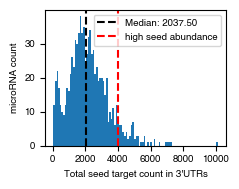

In [ ]:
plt.figure(figsize=(2.4, 1.9))
plt.hist(all_total_seed_counts_3utr.values(), bins=100, alpha=1)
plt.xlabel("Total seed target count in 3'UTRs")
plt.ylabel("microRNA count")
median_3utr = np.median(list(all_total_seed_counts_3utr.values()))
plt.axvline(median_3utr, color="black", linestyle="--", label=f"Median: {median_3utr:.2f}")
plt.axvline(4000, color="red", linestyle="--", label="high seed abundance")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, "19_total_seed_counts_3utr.svg"), dpi=300)

# Load cell line expression data

In [39]:
cell_lines_subset = ["HEK293T", "HeLa", "SKNSH", "MCF7", "HUH7", "A549"]
cell_lines_rest = ["HaCaT", "JEG3", "Tera1", "PC3"]
cell_lines_additional = ["K562"]
cell_lines_measured = cell_lines_subset + cell_lines_rest + cell_lines_additional

In [40]:
mRNA_expression = pd.read_csv('../microrna_data/mRNA_data/rna_cellline.tsv', sep='\t')
cell_lines_data = mRNA_expression['Cell line'].unique()

# Convert all entries to lowercase to ensure case-insensitivity
cell_lines_data = [line.upper() for line in cell_lines_data]
cell_lines_measured = [line.upper() for line in cell_lines_measured]

import difflib
matches = {data_line: difflib.get_close_matches(data_line, cell_lines_data, n=2, cutoff=0.8)[0]
           if difflib.get_close_matches(data_line, cell_lines_data, n=2, cutoff=0.8)
           else None for data_line in cell_lines_measured}

# 'invert' matches for renaming purposes
matches_invert = {v: k for k, v in matches.items()}

# make the cell line name upper
mRNA_expression['Cell line'] = mRNA_expression['Cell line'].apply(lambda x: x.upper())

# remove the cell lines that are not in the list
mRNA_expression = mRNA_expression[mRNA_expression['Cell line'].isin(matches.values())]

# rename the cell ines according to matches
mRNA_expression = mRNA_expression.replace({'Cell line': matches_invert})

mRNA_expression["cell_line_gene_name"] = mRNA_expression["Cell line"] + "_" + mRNA_expression["Gene name"]

# Look for duplicates and only keep the first one
mRNA_expression = mRNA_expression.drop_duplicates(subset="cell_line_gene_name", keep="first")

In [41]:
# Pivot the table
expression_pivot = mRNA_expression.pivot(index="Gene name", columns="Cell line", values="nTPM")

# Optional: Reset index if needed
expression_pivot.index.name = None  # Remove the index name
expression_pivot.columns.name = None  # Remove the columns name

In [42]:
# make seed_counts_by_record_full a dataframe with seed_target_id as index and gene_name as columns
seed_counts_by_record_full_df = pd.DataFrame(seed_counts_by_record_full)
seed_counts_by_record_full_df = seed_counts_by_record_full_df.T
seed_counts_by_record_3utr_df = pd.DataFrame(seed_counts_by_record_3utr)
seed_counts_by_record_3utr_df = seed_counts_by_record_3utr_df.T

In [43]:
# harmonize the two indices
shared_index = expression_pivot.index.intersection(seed_counts_by_record_full_df.index)
expression_pivot = expression_pivot.loc[shared_index]
seed_counts_by_record_full_df = seed_counts_by_record_full_df.loc[shared_index]
seed_counts_by_record_3utr_df = seed_counts_by_record_3utr_df.loc[shared_index]

In [44]:
total_seed_counts_by_cell_line_full = {}
for cell_line in expression_pivot.columns:
    cell_line_expression = expression_pivot[cell_line]
    multiplied_seed_counts = seed_counts_by_record_full_df.multiply(cell_line_expression, axis=0)
    summed_seed_counts = multiplied_seed_counts.sum(axis=0)
    total_seed_counts_by_cell_line_full[cell_line] = summed_seed_counts
total_seed_counts_by_cell_line_full = pd.DataFrame(total_seed_counts_by_cell_line_full)

In [45]:
total_seed_counts_by_cell_line_3utr = {}
for cell_line in expression_pivot.columns:
    cell_line_expression = expression_pivot[cell_line]
    multiplied_seed_counts = seed_counts_by_record_3utr_df.multiply(cell_line_expression, axis=0)
    summed_seed_counts = multiplied_seed_counts.sum(axis=0)
    total_seed_counts_by_cell_line_3utr[cell_line] = summed_seed_counts
total_seed_counts_by_cell_line_3utr = pd.DataFrame(total_seed_counts_by_cell_line_3utr)

In [46]:
# This is the expression-independent total seed count
total_seed_counts_by_cell_line_full["genome_wide_total"] = all_total_seed_counts_full
total_seed_counts_by_cell_line_3utr["genome_wide_total"] = all_total_seed_counts_3utr

In [ ]:
%%capture output
r2_by_cell_line = {}
for cell_line in total_seed_counts_by_cell_line_full.columns[:-1]:
    x = np.log10(total_seed_counts_by_cell_line_full["genome_wide_total"])
    y = np.log10(total_seed_counts_by_cell_line_full[cell_line])
    x = x.dropna()
    y = y.dropna()
    common_index = x.index.intersection(y.index)
    x = x.loc[common_index]
    y = y.loc[common_index]
    
    plt.figure(figsize=(2, 1.8))
    plt.scatter(x, y, s=1, rasterized=True)
    plt.xlabel(r"$\log_{10}$(3'UTR seed count genome)")
    plt.ylabel(r"$\log_{10}$(RNA-seq expression-adjusted" + f"\n3'UTR seed count ({cell_line})")
    r2 = np.corrcoef(x, y)[0, 1]**2
    plt.title(f"{cell_line}: R2: {r2:.2f}")
    plt.tight_layout()
    plt.savefig(os.path.join(plot_folder, f"19_total_seed_counts_by_cell_line_3utr_{cell_line}.svg"), dpi=300)
    
    r2_by_cell_line[cell_line] = r2
r2_by_cell_line = pd.Series(r2_by_cell_line).to_frame()

C:\Users\loesi\AppData\Local\Temp\ipykernel_14272\3356330349.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


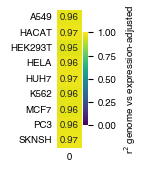

In [48]:
plt.figure(figsize=(0.4, 1.8))
sns.heatmap(r2_by_cell_line, annot=True, cmap="viridis", vmin=0, vmax=1, cbar_kws={"label": "r$^2$ genome vs expression-adjusted", "shrink": 1.8})
plt.tick_params(length=0)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, "19_r2_by_cell_line.svg"), dpi=300)

In [49]:
mirbase["seed_abundance"] = mirbase["seed_target"].map(total_seed_counts_by_cell_line_3utr["genome_wide_total"])

# Compare with deviation

In [50]:
# load popt
with open("../outputs/3_fitting/combined_dataset/combined_dataset_popt.pkl", "rb") as f:
    popt = pickle.load(f)

from library2_utils.transfer_functions import transfer_function

In [51]:
knockdown_filter = pd.read_csv("../outputs/3_fitting/combined_dataset_filter/combined_dataset_filter_knockdown.csv", index_col=0)

In [52]:
deviation_df = pd.read_csv("../outputs/3_fitting/combined_dataset/combined_dataset_deviation_bias_aware.csv", index_col=0)
deviation_df = deviation_df.loc[knockdown_filter.index]

In [53]:
cell_lines_measured = deviation_df.columns

In [54]:
# expression filtering
df_merge_crosstalk_filter = pd.read_csv("../microrna_data/3_output/Alles_Keller_combined_expression_congruent.csv", index_col=0).dropna()

# remove "hsa-miR-3613-3p" if present
if "hsa-miR-3613-3p" in df_merge_crosstalk_filter.index:
    df_merge = df_merge_crosstalk_filter.drop("hsa-miR-3613-3p", axis=0)

Deviation is calculated as measured - predicted. Thus, a positive value implies less knockdown than expected.

In [55]:
high_seed_abundance = mirbase[mirbase.loc[mirbase.index, "seed_abundance"] > 4000].index
high_seed_abundance = knockdown_filter[knockdown_filter.index.isin(high_seed_abundance)].index

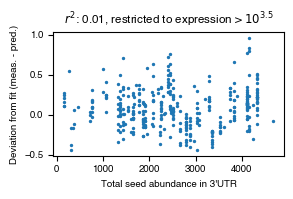

In [58]:
all_x_vals = []
all_y_vals = []
highly_abundant_by_cell_line = {}
for cell_line in cell_lines_measured:
    expression_filter = df_merge_crosstalk_filter[df_merge_crosstalk_filter[cell_line] > 3.5].index
    #expression_filter = expression_filter[expression_filter[cell_line] < 4.0].index
    deviation_df_filtered = deviation_df[deviation_df.index.isin(expression_filter)]
    all_x_vals.append(mirbase.loc[deviation_df_filtered.index, "seed_abundance"].values)
    all_y_vals.append(deviation_df_filtered[cell_line].values)
    highly_abundant_by_cell_line[cell_line] = mirbase[mirbase.index.isin(deviation_df_filtered.index) & (mirbase["seed_abundance"] > 4000)].index

all_x_vals = np.concatenate(all_x_vals)
all_y_vals = np.concatenate(all_y_vals)

plt.figure(figsize=(3, 2))
plt.scatter(all_x_vals, all_y_vals, s=2)
r2 = np.corrcoef(all_x_vals, all_y_vals)[0, 1]**2
plt.title(f"$r^2$: {r2:.2f}, restricted to expression > " + r"$10^{3.5}$")
plt.xlabel("Total seed abundance in 3'UTR")
plt.ylabel("Deviation from fit (meas. - pred.)")
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, f"19_seed_abundance_vs_deviation.svg"), dpi=300)

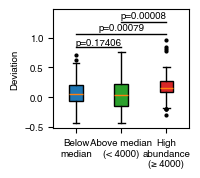

In [59]:
# Calculate median seed abundance from 3' UTR data
median_abundance = np.median(mirbase["seed_abundance"])
high_abundance_threshold = 4000

# Create groups for comparison
below_median_abundance_values = []
above_median_abundance_values = []
high_abundance_values = []

below_median_abundance_mirnas = mirbase[mirbase["seed_abundance"] < median_abundance].index
above_median_abundance_mirnas = mirbase[(mirbase["seed_abundance"] >= median_abundance) & (mirbase["seed_abundance"] < high_abundance_threshold)].index
high_abundance_mirnas = mirbase[mirbase["seed_abundance"] >= high_abundance_threshold].index

for cell_line in cell_lines_measured:
    # Get expressed miRNAs for this cell line
    expression_filter = df_merge_crosstalk_filter[df_merge_crosstalk_filter[cell_line] > 3.5].index
    
    # Filter deviations by expression
    deviation_filtered = deviation_df[deviation_df.index.isin(expression_filter)]
    
    # Split into high/low abundance groups
    below_median_abundance = deviation_filtered[cell_line][mirbase.loc[deviation_filtered.index, "seed_abundance"] < median_abundance].values
    above_median_abundance = deviation_filtered[cell_line][
        (mirbase.loc[deviation_filtered.index, "seed_abundance"] >= median_abundance)
        & (mirbase.loc[deviation_filtered.index, "seed_abundance"] < high_abundance_threshold)
        ].values
    high_abundance = deviation_filtered[cell_line][mirbase.loc[deviation_filtered.index, "seed_abundance"] >= high_abundance_threshold].values
    
    below_median_abundance_values.extend(below_median_abundance)
    above_median_abundance_values.extend(above_median_abundance)
    high_abundance_values.extend(high_abundance)

# Perform pairwise Mann-Whitney U tests
from scipy import stats

# Test 1: Below median vs Above median (but below high threshold)
stat1, pval1 = stats.mannwhitneyu(below_median_abundance_values, above_median_abundance_values, alternative='two-sided')

# Test 2: Below median vs High abundance
stat2, pval2 = stats.mannwhitneyu(below_median_abundance_values, high_abundance_values, alternative='two-sided')

# Test 3: Above median vs High abundance
stat3, pval3 = stats.mannwhitneyu(above_median_abundance_values, high_abundance_values, alternative='two-sided')

# Create boxplot
plt.figure(figsize=(2, 1.8))
box_data = [below_median_abundance_values, above_median_abundance_values, high_abundance_values]
bp = plt.boxplot(box_data, patch_artist=True, flierprops=dict(marker='o', markerfacecolor='black', markersize=2))

# Customize boxplot colors
colors = ['tab:blue', 'tab:green', 'tab:red']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Add labels
plt.xticks([1, 2, 3], ['Below\nmedian', 'Above median\n(< 4000)', 'High\nabundance\n(≥ 4000)'])
plt.ylabel('Deviation')

# Add statistical significance lines and p-values
y_max = max([max(data) for data in box_data])
y_range = y_max - min([min(data) for data in box_data])
line_height = 0.85

# Line 1: Between groups 1 and 2
plt.plot([1, 2], [line_height, line_height], 'k-', linewidth=1)
plt.text(1.5, line_height, f'p={pval1:.5f}', ha='center', va='bottom', fontsize=7)

# Line 2: Between groups 1 and 3
line_height2 = line_height + 0.15 * y_range
plt.plot([1, 3], [line_height2, line_height2], 'k-', linewidth=1)
plt.text(2, line_height2 + 0.02 * y_range, f'p={pval2:.5f}', ha='center', va='bottom', fontsize=7)

# Line 3: Between groups 2 and 3
line_height3 = line_height + 0.3 * y_range
plt.plot([2, 3], [line_height3, line_height3], 'k-', linewidth=1)
plt.text(2.5, line_height3 + 0.02 * y_range, f'p={pval3:.5f}', ha='center', va='bottom', fontsize=7)

# Adjust y-axis limits to accommodate the significance lines
plt.ylim(bottom=None, top=line_height3 + 0.15 * y_range)

# Save plot
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, "19_abundance_deviation_boxplot.svg"), dpi=300, bbox_inches='tight')

In [64]:
combined_abundance = np.concatenate([below_median_abundance_values, above_median_abundance_values])
np.mean(high_abundance_values) - np.mean(combined_abundance)

np.float64(0.12878811044761343)

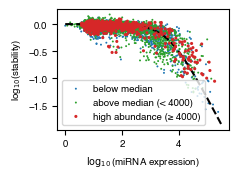

In [66]:
x_vals_log = np.arange(0, 5.5, 0.01)
x_vals = 10**x_vals_log
y_vals = np.log10(transfer_function(x_vals, *popt))

below_in_data = below_median_abundance_mirnas.intersection(df_merge_crosstalk_filter.index)
above_in_data = above_median_abundance_mirnas.intersection(df_merge_crosstalk_filter.index)
high_in_data = high_abundance_mirnas.intersection(df_merge_crosstalk_filter.index)

plt.figure(figsize=(2.4, 1.8))
for i, cell_line in enumerate(cell_lines_measured):
    plt.scatter(df_merge_crosstalk_filter[cell_line].loc[below_in_data], knockdown_filter[cell_line].loc[below_in_data],
                s=2, edgecolor="none", color="tab:blue", zorder=1, rasterized=True, label="below median" if i == 0 else None)   
    plt.scatter(df_merge_crosstalk_filter[cell_line].loc[above_in_data], knockdown_filter[cell_line].loc[above_in_data],
                color="tab:green", s=2, edgecolor="none", zorder=2, rasterized=True, label="above median (< 4000)" if i == 0 else None)
    plt.scatter(df_merge_crosstalk_filter[cell_line].loc[high_in_data], knockdown_filter[cell_line].loc[high_in_data],
                color="tab:red", s=5, edgecolor="none", zorder=3, rasterized=True, label="high abundance (≥ 4000)" if i == 0 else None)
    plt.xlabel(r"$\log_{10}$(miRNA expression)")
    plt.ylabel(r"log$_{10}$(stability)")
plt.plot(x_vals_log, y_vals, color="black", linestyle="--")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, f"19_expression_vs_deviation_all.svg"), dpi=300)
